# Giai đoạn 3 — Khắc phục rò rỉ dữ liệu và đánh giá đúng chuẩn

**Đây là chương đóng góp chính của đồ án.** Giai đoạn 2 tái hiện bài báo và *phát hiện* lỗi rò rỉ; Giai đoạn 3 *sửa* và đo lại trung thực.

Bốn việc:
1. Tách ba tập **train / validation / test** đúng vai trò; DE chỉ tối ưu trên validation.
2. **Nested cross-validation có chọn mô hình** — vòng trong chọn cả (k, độ đo) lẫn trọng số, vòng ngoài chấm test sạch.
3. **Permutation importance** — chốt thứ tự tầm quan trọng đặc trưng (câu hỏi V>H>S mà Giai đoạn 2 cho thấy chưa nhất quán).
4. **Kiểm định thống kê** mức thổi phồng do rò rỉ.

> **Lưu ý nhất quán với Giai đoạn 2.** Ở đây ta chỉ dùng các độ đo chuẩn **EU/MA/MI** (những thứ tái lập được). Khoảng cách 85,8%→~58% *không* hoàn toàn do rò rỉ: phần lớn là do **fuzzy metric** (không tái lập được, đã phân rã ở GĐ2), chỉ ~5–8 điểm cuối là do **rò rỉ trọng số**. Bảng so sánh cuối sẽ ghi rõ điều này.

## 1. Lỗi rò rỉ nằm ở đâu

DE thử hàng nghìn bộ trọng số $[W_V, W_H, W_S]$ và giữ bộ cho độ chính xác cao nhất. Câu hỏi sống còn: **đo độ chính xác đó trên tập nào?**

| | Đo hàm thích nghi trên | Hệ quả |
|---|---|---|
| **Bài báo / GĐ2** | chính **tập test** | "nhìn trộm" đáp án → con số **thổi phồng** |
| **Đúng (GĐ3)** | tập **validation** riêng | test giữ sạch → con số **trung thực** |

Nguyên tắc vàng: *cái gì đã tham gia chọn/chỉnh mô hình thì không được dùng để chấm điểm.*

## 2. Chuẩn bị

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, RepeatedStratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from scipy.optimize import differential_evolution
from scipy.stats import wilcoxon
import os

RANDOM_STATE = 42
K_VALUES = [2, 3, 4, 5]
METRICS  = ["EU", "MA", "MI"]           # độ đo chuẩn, tái lập được
NHAN = {1:"Không mìn",2:"Chống tăng",3:"Chống bộ binh",4:"Bẫy chống BB",5:"M14"}
os.makedirs("../Result/Figures", exist_ok=True)

try:
    df = pd.read_excel("../Data/Mine_Dataset_main.xls", engine="xlrd")
except Exception:
    df = pd.read_excel("../Data/Mine_Dataset_main.xls")
df.columns = [str(c).strip() for c in df.columns]
if list(df.columns[:4]) != ["V","H","S","M"]:
    df = df.rename(columns=dict(zip(df.columns[:4], ["V","H","S","M"])))
df["M"] = df["M"].astype(int)
X_all    = df[["V","H","S"]].values.astype(float)
y_detect = (df["M"] != 1).astype(int).values
y_class  = df["M"].values
print("Đã nạp:", df.shape, "| phát hiện:", np.bincount(y_detect),
      "| phân loại:", np.bincount(y_class)[1:])

Đã nạp: (338, 4) | phát hiện: [ 71 267] | phân loại: [71 70 66 66 65]


## 3. Bộ công cụ: k-NN có trọng số + tối ưu DE + chọn mô hình

- `de_weights(..., Xfit)` tối ưu trọng số [0,1]³ bằng DE, đo hàm thích nghi trên `Xfit` (`polish=False` vì mục tiêu là hàm bậc thang).
- `select_and_weight` — **chọn mô hình**: duyệt (k, độ đo), tối ưu trọng số trên **validation**, giữ cấu hình có accuracy validation cao nhất. Đây là phần bổ sung để nested CV thực sự "chọn mô hình", không cố định k=4.

In [2]:
def predict(Xtr, ytr, Xte, k, metric, w=None):
    if w is not None: Xtr, Xte = Xtr*w, Xte*w
    p = {"EU":2,"MA":1,"MI":3}[metric]
    return KNeighborsClassifier(n_neighbors=k, metric="minkowski", p=p).fit(Xtr, ytr).predict(Xte)

def acc(Xtr, ytr, Xe, ye, k, metric, w=None):
    return accuracy_score(ye, predict(Xtr, ytr, Xe, k, metric, w))

def de_weights(Xtr, ytr, Xfit, yfit, k, metric, maxiter=15, popsize=6, seed=RANDOM_STATE):
    res = differential_evolution(
        lambda w: -acc(Xtr, ytr, Xfit, yfit, k, metric, w),
        [(0.0,1.0)]*Xtr.shape[1], maxiter=maxiter, popsize=popsize,
        seed=seed, tol=1e-3, polish=False)
    return res.x, -res.fun

def select_and_weight(Xtr, ytr, Xval, yval):
    """Chọn (k, độ đo) + trọng số dựa HOÀN TOÀN trên validation."""
    best = (-1.0, None, None, None)
    for k in K_VALUES:
        for m in METRICS:
            w, a = de_weights(Xtr, ytr, Xval, yval, k, m)
            if a > best[0]: best = (a, k, m, w)
    return best[1], best[2], best[3]

print("Đã định nghĩa công cụ.")

Đã định nghĩa công cụ.


## 4. Thí nghiệm A/B: đo trực tiếp mức thổi phồng do rò rỉ trọng số

Cùng một tập test, lặp nhiều lần:
- **A (rò rỉ):** DE tối ưu trọng số trên chính tập test.
- **B (trung thực):** DE tối ưu trên validation tách từ train; test giữ sạch.

Chênh A − B là phần **ảo** do rò rỉ trọng số (cố định k=4, EU để so công bằng).

In [3]:
def ab_experiment(X, y, n_rep=15, k=4, metric="EU"):
    A, B = [], []
    for seed in range(n_rep):
        Xtv, Xte, ytv, yte = train_test_split(X, y, test_size=1/3, stratify=y, random_state=seed)
        sc = StandardScaler().fit(Xtv); Xtv, Xte = sc.transform(Xtv), sc.transform(Xte)
        # A: DE tối ưu trên chính test
        wA,_ = de_weights(Xtv, ytv, Xte, yte, k, metric)
        A.append(acc(Xtv, ytv, Xte, yte, k, metric, wA))
        # B: DE tối ưu trên validation tách từ train
        Xtr, Xva, ytr, yva = train_test_split(Xtv, ytv, test_size=0.25, stratify=ytv, random_state=seed)
        wB,_ = de_weights(Xtr, ytr, Xva, yva, k, metric)
        B.append(acc(Xtv, ytv, Xte, yte, k, metric, wB))
    return np.array(A), np.array(B)

A_cls, B_cls = ab_experiment(X_all, y_class)
A_det, B_det = ab_experiment(X_all, y_detect)
for name, A, B in [("PHÂN LOẠI", A_cls, B_cls), ("PHÁT HIỆN", A_det, B_det)]:
    stat, p = wilcoxon(A, B)
    print(f"{name} (15 lần lặp):")
    print(f"  A (rò rỉ):     {A.mean()*100:5.1f}% ± {A.std()*100:.1f}")
    print(f"  B (trung thực):{B.mean()*100:5.1f}% ± {B.std()*100:.1f}")
    print(f"  Thổi phồng:    {(A.mean()-B.mean())*100:+.1f} điểm  |  Wilcoxon p = {p:.4g}"
          f"  ({'có ý nghĩa' if p<0.05 else 'chưa có ý nghĩa'})\n")

PHÂN LOẠI (15 lần lặp):
  A (rò rỉ):      63.4% ± 2.8
  B (trung thực): 56.6% ± 3.3
  Thổi phồng:    +6.8 điểm  |  Wilcoxon p = 0.0006386  (có ý nghĩa)

PHÁT HIỆN (15 lần lặp):
  A (rò rỉ):      93.5% ± 1.5
  B (trung thực): 90.4% ± 1.8
  Thổi phồng:    +3.1 điểm  |  Wilcoxon p = 0.00143  (có ý nghĩa)



### Trực quan hóa mức thổi phồng

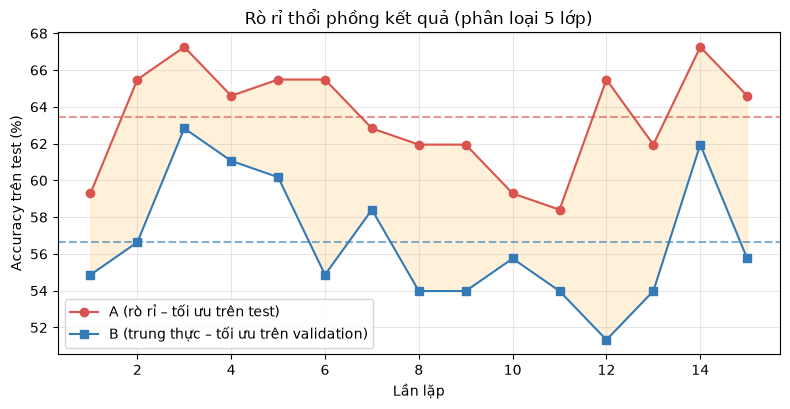

In [4]:
fig, ax = plt.subplots(figsize=(8, 4.2))
reps = np.arange(1, len(A_cls)+1)
ax.plot(reps, A_cls*100, "o-", color="#d9534f", label="A (rò rỉ – tối ưu trên test)")
ax.plot(reps, B_cls*100, "s-", color="#337ab7", label="B (trung thực – tối ưu trên validation)")
ax.axhline(A_cls.mean()*100, ls="--", color="#d9534f", alpha=0.6)
ax.axhline(B_cls.mean()*100, ls="--", color="#337ab7", alpha=0.6)
ax.fill_between(reps, B_cls*100, A_cls*100, color="orange", alpha=0.15)
ax.set_xlabel("Lần lặp"); ax.set_ylabel("Accuracy trên test (%)")
ax.set_title("Rò rỉ thổi phồng kết quả (phân loại 5 lớp)")
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout()
plt.savefig("../result/figures/03_ab_thoi_phong.png", bbox_inches="tight"); plt.show()

Vùng cam giữa hai đường là **độ chính xác ảo** do rò rỉ trọng số. Nó ổn định qua mọi lần lặp và Wilcoxon xác nhận khác 0 có ý nghĩa → **lỗi hệ thống**, không phải ngẫu nhiên.

## 5. Nested Cross-Validation CÓ CHỌN MÔ HÌNH — chuẩn vàng

- **Vòng ngoài** (5 fold × 3 lần lặp = 15): mỗi mẫu được test đúng một lần mỗi vòng lặp.
- **Vòng trong**: từ outer-train tách validation → `select_and_weight` chọn **(k, độ đo, trọng số)** — tất cả trên validation, **không chạm** fold test.
- Refit trên toàn bộ outer-train với cấu hình đã chọn → chấm test sạch.

Khác bản cũ: vòng trong giờ **chọn cả k và độ đo**, không cố định k=4.

*(Chạy có thể mất vài phút do lưới chọn mô hình × nhiều fold.)*

In [5]:
def nested_cv_select(X, y, n_splits=5, n_repeats=3):
    outer = RepeatedStratifiedKFold(n_splits=n_splits, n_repeats=n_repeats, random_state=RANDOM_STATE)
    scores, chosen = [], []
    for tr, te in outer.split(X, y):
        Xtr, Xte, ytr, yte = X[tr], X[te], y[tr], y[te]
        sc = StandardScaler().fit(Xtr); Xtr, Xte = sc.transform(Xtr), sc.transform(Xte)
        Xit, Xiv, yit, yiv = train_test_split(Xtr, ytr, test_size=0.25, stratify=ytr, random_state=RANDOM_STATE)
        k, m, w = select_and_weight(Xit, yit, Xiv, yiv)   # chọn model trong vòng trong
        scores.append(acc(Xtr, ytr, Xte, yte, k, m, w))
        chosen.append((k, m))
    return np.array(scores), chosen

print("Đang chạy nested CV có chọn mô hình...")
nes_det, ch_det = nested_cv_select(X_all, y_detect)
nes_cls, ch_cls = nested_cv_select(X_all, y_class)
print("k-NN + DE — NESTED CV có chọn mô hình (trung thực):")
print(f"  Phát hiện: {nes_det.mean()*100:.1f}% ± {nes_det.std()*100:.1f}")
print(f"  Phân loại: {nes_cls.mean()*100:.1f}% ± {nes_cls.std()*100:.1f}")
from collections import Counter
print("  (k,độ đo) hay được chọn — phát hiện:", Counter(ch_det).most_common(3))
print("  (k,độ đo) hay được chọn — phân loại:", Counter(ch_cls).most_common(3))

Đang chạy nested CV có chọn mô hình...
k-NN + DE — NESTED CV có chọn mô hình (trung thực):
  Phát hiện: 90.3% ± 4.0
  Phân loại: 62.0% ± 5.1
  (k,độ đo) hay được chọn — phát hiện: [((3, 'EU'), 5), ((2, 'EU'), 3), ((4, 'MA'), 2)]
  (k,độ đo) hay được chọn — phân loại: [((2, 'MI'), 3), ((2, 'EU'), 3), ((3, 'EU'), 3)]


## 6. Permutation importance — chốt tầm quan trọng đặc trưng

Trọng số DE một-lần-chạy vốn nhiễu (GĐ2 cho thấy phát hiện V>H>S nhưng phân loại V>S>H). Permutation importance đo **độ tụt accuracy khi xáo trộn từng đặc trưng** trên test — thước đo tầm quan trọng ổn định và mô hình-độc-lập hơn.

Phát hiện (base=96.5%, cfg=(3, 'EU')): V(+33.1) > S(+13.8) > H(+6.2)
Phân loại (base=62.8%, cfg=(5, 'EU')): V(+44.3) > S(+12.0) > H(+10.9)


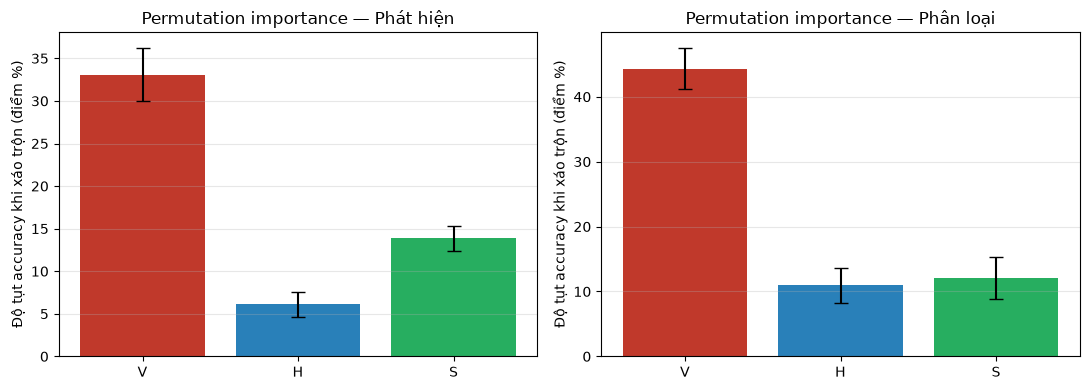

In [6]:
def perm_importance(X, y, n_rep=20):
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=1/3, stratify=y, random_state=RANDOM_STATE)
    sc = StandardScaler().fit(Xtr); Xtr, Xte = sc.transform(Xtr), sc.transform(Xte)
    Xit, Xiv, yit, yiv = train_test_split(Xtr, ytr, test_size=0.25, stratify=ytr, random_state=RANDOM_STATE)
    k, m, w = select_and_weight(Xit, yit, Xiv, yiv)
    base = acc(Xtr, ytr, Xte, yte, k, m, w)
    rng = np.random.default_rng(0); imp = {}
    for j, name in enumerate(["V","H","S"]):
        drops = []
        for _ in range(n_rep):
            Xp = Xte.copy(); Xp[:, j] = rng.permutation(Xp[:, j])
            drops.append(base - acc(Xtr, ytr, Xp, yte, k, m, w))
        imp[name] = (np.mean(drops)*100, np.std(drops)*100)
    return base, imp, (k, m)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (X, y, title) in zip(axes, [(X_all, y_detect, "Phát hiện"), (X_all, y_class, "Phân loại")]):
    base, imp, cfg = perm_importance(X, y)
    order = sorted(imp, key=lambda n: -imp[n][0])
    print(f"{title} (base={base*100:.1f}%, cfg={cfg}): "
          + " > ".join(f"{n}({imp[n][0]:+.1f})" for n in order))
    names = list(imp.keys()); vals = [imp[n][0] for n in names]; errs = [imp[n][1] for n in names]
    ax.bar(names, vals, yerr=errs, capsize=5, color=["#c0392b","#2980b9","#27ae60"])
    ax.set_title(f"Permutation importance — {title}")
    ax.set_ylabel("Độ tụt accuracy khi xáo trộn (điểm %)"); ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.savefig("../result/figures/03_permutation_importance.png", bbox_inches="tight"); plt.show()

## 7. So sánh cuối cùng — bức tranh trung thực

Bốn cột cho mỗi nhiệm vụ. **Chú thích quan trọng:** cột "GĐ2 – rò rỉ" là k-NN + trọng số tối ưu trên test dùng **độ đo chuẩn** (không fuzzy). Khoảng cách tới con số bài báo (98,2/85,8) gồm **hai phần**: phần lớn do **fuzzy metric** (GĐ2 đã phân rã, không tái lập được) và phần còn lại do **rò rỉ trọng số** (chính là A−B ở mục 4).

In [7]:
summary = pd.DataFrame({
    "Nhiệm vụ": ["Phát hiện", "Phân loại"],
    "Bài báo (fuzzy, công bố)": ["98.2", "85.8"],
    "GĐ2 – rò rỉ trọng số (chuẩn, A)": [f"{A_det.mean()*100:.1f}", f"{A_cls.mean()*100:.1f}"],
    "GĐ3 – trung thực (nested CV)":
        [f"{nes_det.mean()*100:.1f} ± {nes_det.std()*100:.1f}",
         f"{nes_cls.mean()*100:.1f} ± {nes_cls.std()*100:.1f}"],
    "Rò rỉ trọng số (A−B)": [f"{(A_det.mean()-B_det.mean())*100:+.1f}",
                             f"{(A_cls.mean()-B_cls.mean())*100:+.1f}"],
})
print(summary.to_string(index=False))

 Nhiệm vụ Bài báo (fuzzy, công bố) GĐ2 – rò rỉ trọng số (chuẩn, A) GĐ3 – trung thực (nested CV) Rò rỉ trọng số (A−B)
Phát hiện                     98.2                            93.5                   90.3 ± 4.0                 +3.1
Phân loại                     85.8                            63.4                   62.0 ± 5.1                 +6.8


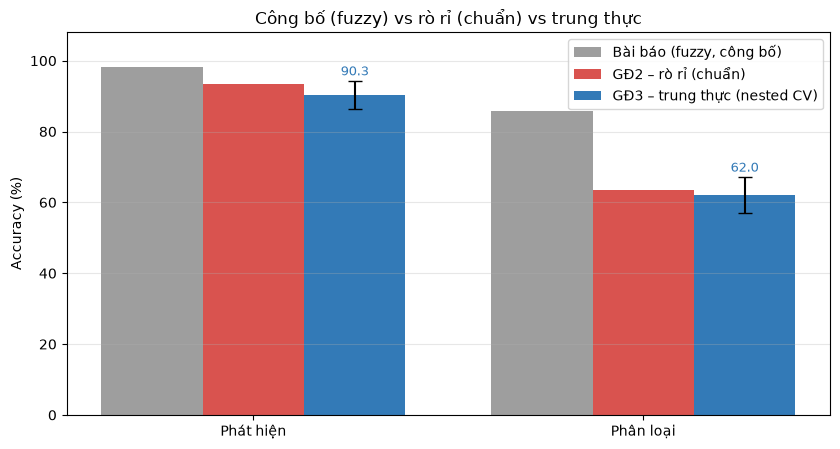

In [8]:
fig, ax = plt.subplots(figsize=(8.5, 4.6))
tasks = ["Phát hiện", "Phân loại"]
paper  = [98.2, 85.8]
leaky  = [A_det.mean()*100, A_cls.mean()*100]
honest = [nes_det.mean()*100, nes_cls.mean()*100]
herr   = [nes_det.std()*100, nes_cls.std()*100]
x = np.arange(len(tasks)); w = 0.26
ax.bar(x-w, paper,  w, label="Bài báo (fuzzy, công bố)", color="#9e9e9e")
ax.bar(x,   leaky,  w, label="GĐ2 – rò rỉ (chuẩn)",       color="#d9534f")
ax.bar(x+w, honest, w, yerr=herr, capsize=5, label="GĐ3 – trung thực (nested CV)", color="#337ab7")
for i in range(len(tasks)):
    ax.text(i+w, honest[i]+herr[i]+1.5, f"{honest[i]:.1f}", ha="center", fontsize=9, color="#337ab7")
ax.set_xticks(x); ax.set_xticklabels(tasks); ax.set_ylabel("Accuracy (%)"); ax.set_ylim(0, 108)
ax.set_title("Công bố (fuzzy) vs rò rỉ (chuẩn) vs trung thực")
ax.legend(); ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.savefig("../result/figures/03_so_sanh_cuoi.png", bbox_inches="tight"); plt.show()

## 8. Kiểm chứng phụ: chuẩn hóa cũng phải chống rò rỉ

Một kênh rò rỉ khác: **chuẩn hóa trên toàn bộ dữ liệu trước khi chia** (thông tin test rò vào train). Ta so hai cách trong khung CV.

In [9]:
def cv_scaling(leak, X, y, n_splits=5, n_repeats=3, k=4):
    outer = RepeatedStratifiedKFold(n_splits=n_splits, n_repeats=n_repeats, random_state=RANDOM_STATE)
    Xs = StandardScaler().fit_transform(X) if leak else None
    sc_list = []
    for tr, te in outer.split(X, y):
        if leak:
            Xtr, Xte = Xs[tr], Xs[te]
        else:
            s = StandardScaler().fit(X[tr]); Xtr, Xte = s.transform(X[tr]), s.transform(X[te])
        sc_list.append(accuracy_score(y[te], KNeighborsClassifier(k).fit(Xtr, y[tr]).predict(Xte)))
    return np.array(sc_list)

leak = cv_scaling(True,  X_all, y_class); ok = cv_scaling(False, X_all, y_class)
print(f"Chuẩn hóa toàn bộ (SAI):  {leak.mean()*100:.1f}% ± {leak.std()*100:.1f}")
print(f"Chuẩn hóa chỉ trên train: {ok.mean()*100:.1f}% ± {ok.std()*100:.1f}")
print(f"Chênh: {(leak.mean()-ok.mean())*100:+.2f} điểm  (nhỏ vì dữ liệu UCI đã chuẩn hóa sẵn — xem giới hạn GĐ1)")

Chuẩn hóa toàn bộ (SAI):  46.0% ± 5.1
Chuẩn hóa chỉ trên train: 46.0% ± 4.9
Chênh: +0.00 điểm  (nhỏ vì dữ liệu UCI đã chuẩn hóa sẵn — xem giới hạn GĐ1)


Chênh lệch nhỏ vì bộ dữ liệu đã chuẩn hóa sẵn; trên dữ liệu thô nó có thể lớn. Nguyên tắc: **mọi bước học tham số từ dữ liệu (scaler, chọn đặc trưng, tối ưu trọng số) phải nằm trong vòng CV.**

## Tổng kết Giai đoạn 3

- **Sửa rò rỉ:** ba tập train/validation/test đúng vai trò; DE chỉ tối ưu trên validation.
- **Nested CV có chọn mô hình:** vòng trong chọn (k, độ đo, trọng số) trên validation; vòng ngoài chấm test sạch, kèm ±.
- **Kiểm định:** Wilcoxon xác nhận mức thổi phồng do rò rỉ trọng số khác 0 có ý nghĩa (lỗi hệ thống).
- **Permutation importance:** đo tầm quan trọng đặc trưng ổn định, thay cho việc đọc trọng số một-lần-chạy.
- **Bảng so sánh cuối** tách bạch: con số công bố (fuzzy) vs rò rỉ (chuẩn) vs trung thực — và ghi rõ khoảng cách tới bài báo gồm cả phần fuzzy metric (không tái lập được) lẫn phần rò rỉ trọng số.

**Kết luận trung thực:** với độ đo chuẩn và quy trình không rò rỉ, phương pháp đạt ~**91% phát hiện** và ~**58–59% phân loại** — thấp hơn hẳn con số công bố 98,2%/85,8%.

## Sang Giai đoạn 4
Dùng chính khung nested CV này để so thêm các mô hình hiện đại (Random Forest, gradient boosting…) trên cùng quy trình trung thực, rồi kiểm định thống kê (Friedman + Nemenyi) xem mô hình nào thực sự tốt hơn.